# CPU Performance Comparison

Increasing Razor's Edge throughput vs fixed Batch-2 using random input lengths 1-200 chars.


In [1]:
from pathlib import Path
import sys
import os
import psutil

repo_root = Path.cwd()
while not (repo_root / "src").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find 'src' directory in any parent")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(repo_root / "src"))

p = psutil.Process(os.getpid())
if psutil.WINDOWS:
    p.nice(psutil.HIGH_PRIORITY_CLASS)
else:
    try:
        p.nice(-10)
    except psutil.AccessDenied:
        print("Elevation (sudo) is required to set high priority on Unix.")


In [2]:
import asyncio
import time
import random
import string

import matplotlib.pyplot as plt

from batching_executor.process_manager import ComputeExecutor
from demos.cpu.razors_edge_cpu_benchmark_task import RazorsEdgeCPUBenchmarkTask
from demos.cpu.base_batched_cpu_benchmark_task_variants import BaseBatchedCPUBenchmarkTaskB2


def generate_random_strings(n: int, a: int = 1, b: int = 200, seed: int = 42) -> list[str]:
    rng = random.Random(seed)
    chars = string.ascii_letters + string.digits + " "
    result = []
    for _ in range(n):
        length = rng.randint(a, b)
        rand_str = "".join(rng.choice(chars) for _ in range(length))
        result.append(rand_str)
    return result


## Start executor


In [3]:
executor = ComputeExecutor(
    [RazorsEdgeCPUBenchmarkTask, BaseBatchedCPUBenchmarkTaskB2],
    async_limit=16,
    model_thread_limit=1,
)


## Basic functionality check


In [4]:
sample = executor.sync_compute_fn(RazorsEdgeCPUBenchmarkTask, "hello razors edge")
assert isinstance(sample, list)
assert len(sample) > 0
assert isinstance(sample[0], float)
print("sync check 1 passed")

sample = executor.sync_compute_fn(BaseBatchedCPUBenchmarkTaskB2, "hello razors edge")
assert isinstance(sample, list)
assert len(sample) > 0
assert isinstance(sample[0], float)
print("sync check 2 passed")


sync check 1 passed
sync check 2 passed


## Benchmark helpers


In [5]:
async def benchmark_async(target, parallelism_limit: int, request_count: int, seed: int = 42) -> tuple[float, float]:
    payloads = generate_random_strings(request_count, 1, 200, seed=seed)
    start = time.perf_counter()

    semaphore = asyncio.Semaphore(parallelism_limit)

    async def limited_task(*args, **kwargs):
        async with semaphore:
            return await executor.async_compute_fn(*args, **kwargs)

    await asyncio.gather(*(limited_task(target, payload) for payload in payloads))
    elapsed = time.perf_counter() - start
    return elapsed, request_count / elapsed


## Run timing benchmarks


In [6]:
n_req = 200
parallelism_limits = [1, 2, 4, 8, 16]

razors_edge_rps_list = []
for parallelism_limit in parallelism_limits:
    _, a_rps = await benchmark_async(RazorsEdgeCPUBenchmarkTask, parallelism_limit, n_req)
    razors_edge_rps_list.append(a_rps)
    print("Completed benchmark for RazorsEdgeCPUBenchmarkTask with parallelism_limit", parallelism_limit)

batch2_rps_list = []
for parallelism_limit in parallelism_limits:
    _, a_rps = await benchmark_async(BaseBatchedCPUBenchmarkTaskB2, parallelism_limit, n_req)
    batch2_rps_list.append(a_rps)
    print("Completed benchmark for BaseBatchedCPUBenchmarkTaskB2 with parallelism_limit", parallelism_limit)


Completed benchmark for RazorsEdgeCPUBenchmarkTask with parallelism_limit 1
Completed benchmark for RazorsEdgeCPUBenchmarkTask with parallelism_limit 2
Completed benchmark for RazorsEdgeCPUBenchmarkTask with parallelism_limit 4
Completed benchmark for RazorsEdgeCPUBenchmarkTask with parallelism_limit 8
Completed benchmark for RazorsEdgeCPUBenchmarkTask with parallelism_limit 16
Completed benchmark for BaseBatchedCPUBenchmarkTaskB2 with parallelism_limit 1
Completed benchmark for BaseBatchedCPUBenchmarkTaskB2 with parallelism_limit 2
Completed benchmark for BaseBatchedCPUBenchmarkTaskB2 with parallelism_limit 4
Completed benchmark for BaseBatchedCPUBenchmarkTaskB2 with parallelism_limit 8
Completed benchmark for BaseBatchedCPUBenchmarkTaskB2 with parallelism_limit 16


## Diagrams


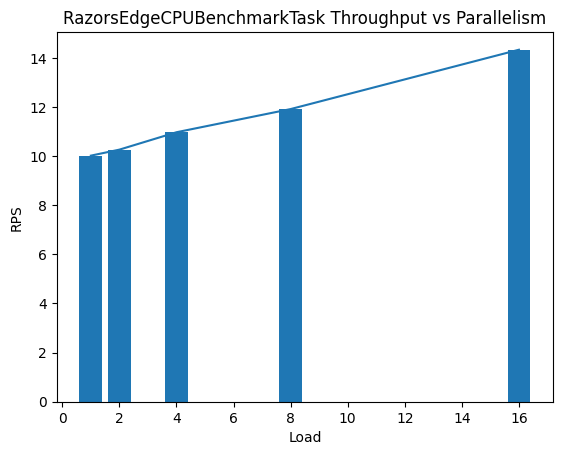

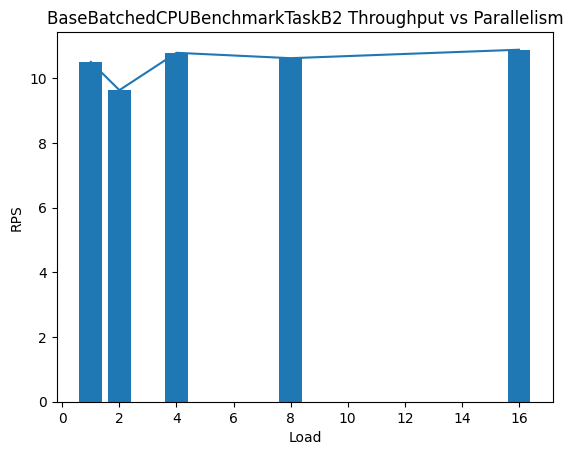

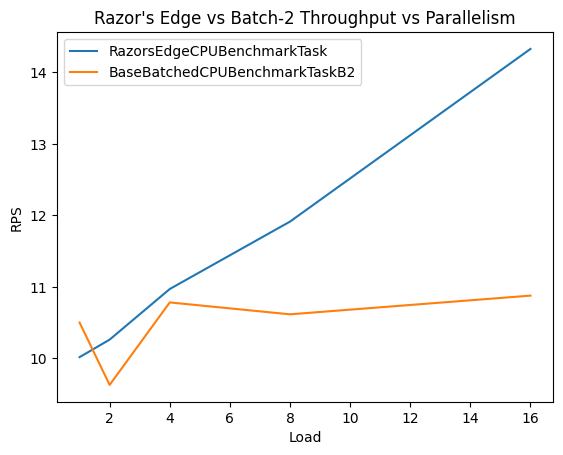

In [7]:
plt.bar(parallelism_limits, razors_edge_rps_list)
plt.plot(parallelism_limits, razors_edge_rps_list)
plt.ylabel("RPS")
plt.xlabel("Load")
plt.title("RazorsEdgeCPUBenchmarkTask Throughput vs Parallelism")
plt.savefig(Path("..") / ".." / "images" / f"{plt.gca().get_title()}.png", bbox_inches="tight")
plt.show()

plt.bar(parallelism_limits, batch2_rps_list)
plt.plot(parallelism_limits, batch2_rps_list)
plt.ylabel("RPS")
plt.xlabel("Load")
plt.title("BaseBatchedCPUBenchmarkTaskB2 Throughput vs Parallelism")
plt.savefig(Path("..") / ".." / "images" / f"{plt.gca().get_title()}.png", bbox_inches="tight")
plt.show()

plt.plot(parallelism_limits, razors_edge_rps_list, label="RazorsEdgeCPUBenchmarkTask")
plt.plot(parallelism_limits, batch2_rps_list, label="BaseBatchedCPUBenchmarkTaskB2")
plt.legend()
plt.ylabel("RPS")
plt.xlabel("Load")
plt.title("Razor's Edge vs Batch-2 Throughput vs Parallelism")
plt.savefig(Path("..") / ".." / "images" / f"{plt.gca().get_title()}.png", bbox_inches="tight")
plt.show()


In [8]:
print(
    "Max Razor's Edge RPS:", max(razors_edge_rps_list),
    "| Max Batch-2 RPS:", max(batch2_rps_list),
    "| Ratio:", max(razors_edge_rps_list) / max(batch2_rps_list)
)


Max Razor's Edge RPS: 14.329063592401821 | Max Batch-2 RPS: 10.877632518969193 | Ratio: 1.317296164161988
